# BlochLaplacian2D — Shifted Laplacian on an orthogonal periodic cell

> **Artifact boundary.** This is notebook-local exploratory teaching material.
> It is not a canonical artifact, supported PhysKit API, real-material model,
> or claim of pedagogical validation. Deterministic plots and numerical outputs
> are embedded so students can inspect the lesson before rerunning it.
>
> Accepted local contract: `docs/harness/physkit.harness.09-dimensional-periodic-solids-notebook-series-contract.md`  
> Accepted contract SHA-256: `97736dc9bb9a5fcd3561b51fea8b2869ecbe1bbb4d1a8b7b2df9d0b4313b9ce9`

## Question

How do independent Bloch phases combine in two dimensions?

## Learning objectives

- Construct one shifted operator per Cartesian direction.
- Assemble the 2D Laplacian with a Kronecker sum.
- Verify Hermiticity and the summed discrete spectrum.
- Recover the ordinary 2D periodic Laplacian at $\mathbf k=0$.

## Shared conventions

Primary calculations use reduced units with $\\hbar^2/(2m)=1$. The first twelve
notebooks use unit baseline box or orthogonal-cell lengths; the final metric
notebooks explicitly define their non-orthogonal lattice bases. PIAB plotting
grids include both hard-wall endpoints. Periodic finite-difference grids are
endpoint-exclusive. Multidimensional meshes use `indexing="ij"` and C-order
flattening, so the last coordinate varies fastest. Eigensolver vectors use
Euclidean normalization; any sampled wavefunction normalization is separately
labelled as uniform quadrature. All helper functions are transparent
notebook-local teaching code, not a public API.

## Connection to the sequence

This extends the gauge-consistent BlochLaplacian1D construction to an orthogonal plane.


## Kronecker construction

For a rectangular cell,

$$
\nabla_{\mathbf k}^2=(\partial_x+ik_x)^2+(\partial_y+ik_y)^2.
$$

With C-order flattening of an array shaped $(N_x,N_y)$,

$$
L_{\mathbf k}=L_{k_x}\otimes I_y+I_x\otimes L_{k_y}.
$$

The ordinary $\nabla^2$ still acts on the full Bloch state; the shifted operator
acts on the periodic factor after removing $e^{i\mathbf k\cdot\mathbf r}$. Each
one-dimensional term uses link phases and is not the same fixed-grid matrix as
a naive discretization of the expanded continuum derivative.


In [1]:
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from io import BytesIO
from IPython.display import Image, display
from scipy import sparse
from scipy.sparse.linalg import eigsh


def bloch_laplacian_1d(n, length, k):
    """Gauge-consistent periodic finite-difference Bloch Laplacian."""
    h = length / n
    rows = np.repeat(np.arange(n), 3)
    columns = np.column_stack((
        (np.arange(n) - 1) % n,
        np.arange(n),
        (np.arange(n) + 1) % n,
    )).ravel()
    values = np.column_stack((
        np.full(n, np.exp(-1j * k * h) / h**2),
        np.full(n, -2.0 / h**2),
        np.full(n, np.exp(1j * k * h) / h**2),
    )).ravel()
    return sparse.coo_matrix((values, (rows, columns)), shape=(n, n)).tocsr()


def hermiticity_error(matrix):
    difference = matrix - matrix.getH()
    return 0.0 if difference.nnz == 0 else np.max(np.abs(difference.data))

np.set_printoptions(precision=6, suppress=True)


def show_figure(figure):
    """Render a deterministic PNG in notebook and saved-output frontends."""
    buffer = BytesIO()
    figure.savefig(buffer, format="png", dpi=120, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))


In [2]:
shape = (25, 25)
lengths = np.ones(2)
q = np.array([0.19, -0.14])
k = 2 * np.pi * q / np.asarray(lengths)
Lx = bloch_laplacian_1d(shape[0], lengths[0], k[0])
Ly = bloch_laplacian_1d(shape[1], lengths[1], k[1])
Ix = sparse.identity(shape[0], format="csr")
Iy = sparse.identity(shape[1], format="csr")
Lk = sparse.kron(Lx, Iy, format="csr") + sparse.kron(Ix, Ly, format="csr")
assert Lk.shape == (shape[0] * shape[1],) * 2
assert np.issubdtype(Lk.dtype, np.complexfloating)
assert hermiticity_error(Lk) < 1e-12
print("matrix shape:", Lk.shape, "nnz:", Lk.nnz)
print("Hermiticity error:", hermiticity_error(Lk))


matrix shape: (625, 625) nnz: 3125
Hermiticity error: 0.0


In [3]:
one_d_spectra = []
for n, length, k_value in zip(shape, lengths, k):
    h = length / n
    G = 2 * np.pi * np.fft.fftfreq(n, d=h)
    one_d_spectra.append(4.0 / h**2 * np.sin(0.5 * (G + k_value) * h) ** 2)
reference = np.sort((one_d_spectra[0][:, None] + one_d_spectra[1][None, :]).ravel())
eigenvalues, eigenvectors = eigsh(-Lk, k=6, which="SA", v0=np.ones(Lk.shape[0]))
order = np.argsort(eigenvalues)
numeric, eigenvectors = eigenvalues[order], eigenvectors[:, order]
residuals = np.array([
    np.linalg.norm((-Lk) @ eigenvectors[:, index] - value * eigenvectors[:, index])
    / max(1.0, abs(value))
    for index, value in enumerate(numeric)
])
assert np.allclose(numeric, reference[:6], rtol=1e-10, atol=1e-12)
assert np.max(residuals) < 1e-8
print("lowest kinetic eigenvalues:", numeric)
print("spectrum tolerance satisfied:", np.allclose(numeric, reference[:6], rtol=1e-10, atol=1e-12))
print("eigensolver residual bound satisfied:", np.max(residuals) < 1e-8)


lowest kinetic eigenvalues: [ 2.198597 26.586157 30.509643 52.381034 54.897202 56.263603]
spectrum tolerance satisfied: True
eigensolver residual bound satisfied: True


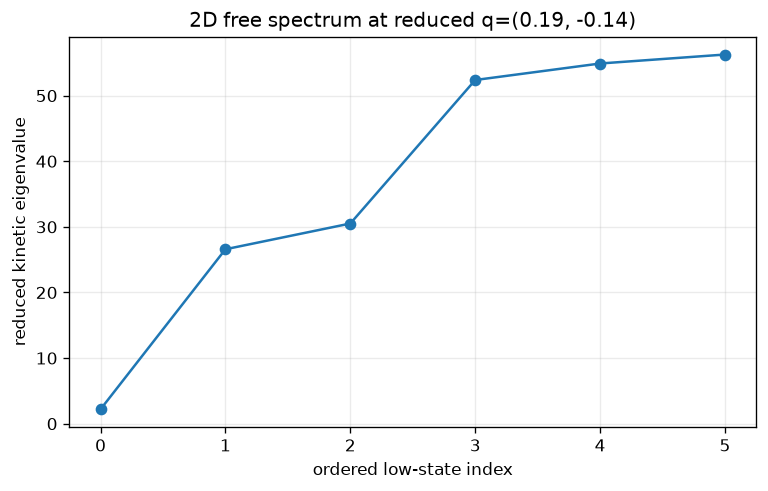

In [4]:
# At k=0, the constant vector is the periodic zero mode.
L0 = (sparse.kron(bloch_laplacian_1d(shape[0], lengths[0], 0.0), Iy, format="csr")
      + sparse.kron(Ix, bloch_laplacian_1d(shape[1], lengths[1], 0.0), format="csr"))
constant = np.ones(shape[0] * shape[1], dtype=complex)
assert np.linalg.norm(L0 @ constant) < 1e-12

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(np.arange(len(numeric)), numeric, "o-")
ax.set(xlabel="ordered low-state index", ylabel="reduced kinetic eigenvalue",
       title=f"2D free spectrum at reduced q={tuple(float(value) for value in q)}")
ax.grid(alpha=0.25)
fig.tight_layout()
show_figure(fig)
plt.close(fig)


## Interpretation and limitations

The Kronecker sum depends on the stated `indexing="ij"` and C-order flattening convention. This notebook uses an orthogonal cell; mixed metric terms are intentionally deferred.

Successful execution checks only the stated formulas and finite calculations.
It is not, by itself, continuum convergence, physical validation, pedagogical
validation, uncertainty quantification, canonical status, or support.

## Connection forward

BlochLaplacian3D adds a third shifted Kronecker term while retaining sparse structure.
